# The AT&T Spam Detection Project : the Deep Learning Module

The following analysis is being done as a mandatory project for certification bloc 4 (Machine Learning Engineer at Jedha).

The goal of this project is to build a spam detector, that can automatically flag spams as they come based solely on the sms' content.

We will implement a modern approach using transfer learning and deep learning models:

- **Sentence Transformers** for semantic text embeddings (transfer learning)
- **Domain-specific feature engineering**
- **Class weighting** to handle imbalanced data
- **Simple & Ultra-Simple Neural Networks** (Deep Learning models for efficient classification)

Designed for Google Colab with GPU acceleration support.

In [1]:
# Install required packages and setup environment
!pip install sentence-transformers torch torchvision torchaudio

In [2]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sentence_transformers import SentenceTransformer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print("✅ Environment setup complete!")
print("🎯 AT&T Spam Detection: Sentence Transformers + Neural Networks")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🚀 CUDA available: {torch.cuda.is_available()}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Using device: {device}")

✅ Environment setup complete!
🎯 AT&T Spam Detection: Sentence Transformers + Neural Networks
🔥 PyTorch version: 2.8.0+cu126
🚀 CUDA available: True
💻 Using device: cuda


# Loading and Cleaning the Data for Analysis

In [3]:
# Upload the spam.csv file here in Colab
from google.colab import files

print("📁 Please upload your spam.csv file now:")
uploaded = files.upload()

if 'spam.csv' in uploaded:
    print("✅ spam.csv uploaded successfully!")
else:
    print("❌ spam.csv not found in uploaded files. Please try uploading again.")

📁 Please upload your spam.csv file now:


Saving spam.csv to spam.csv
✅ spam.csv uploaded successfully!


In [40]:
# Load and explore the dataset
df = pd.read_csv("spam.csv", encoding="latin1")
display(df.head(10))
df.info()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


From this first glance, we can observe that this dataset contains 5572 messages (rows) and that they are labeled as 'spam' or 'ham' which is exactly what is needed to train a spam detector. This data looks complete as we can see (5572 non-null objects for both columns). The other three columns bring nothing to the analysis so we shall drop them.

In [41]:
# Clean the dataset
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

📊 Dataset Overview:
Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Balance:
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


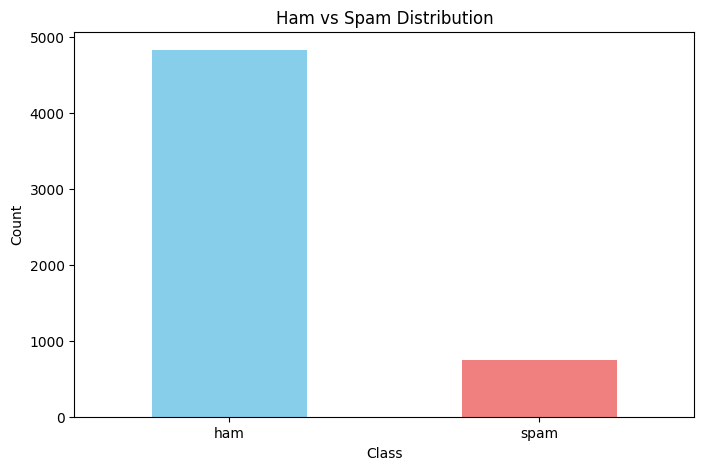

In [42]:
# Dataset Overview and Analysis
print("📊 Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nClass Balance:")
print(df['label'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Ham vs Spam Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

The above plot indicates a significative imbalance in classes distribution which we will surely address this question later on. For now, let's continue the analysis.

In [43]:
# Message length analysis
df['message_length'] = df['message'].str.len()
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


In [44]:
# Word count analysis
df['word_count'] = df['message'].str.split().str.len()
df.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,14.200622,11.424511,1.0,7.0,11.0,19.0,171.0
spam,747.0,23.851406,5.811898,2.0,22.0,25.0,28.0,35.0


In [45]:
# Let's look at some example messages from each class
print("Example Ham Messages:")
print(df[df['label'] == 'ham']['message'].head(5).tolist())
print("\nExample Spam Messages:")
print(df[df['label'] == 'spam']['message'].head(5).tolist())
# This will help us understand the nature of the messages in each category.

Example Ham Messages:
['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...', 'Ok lar... Joking wif u oni...', 'U dun say so early hor... U c already then say...', "Nah I don't think he goes to usf, he lives around here though", 'Even my brother is not like to speak with me. They treat me like aids patent.']

Example Spam Messages:
["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's", "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv", 'WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.', 'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update

## The key insights from the above exploratory analysis

1. Language style:
    - Ham: casual, slangy, personal ("lar", "wif u oni", "hor")
    - Spam: formal, promotional language

2. Vocabulary patterns:
    - Spam keywords: "win", "free", "receive", "reward", "winner" (classic spam indicators)

3. Length differences:

    - Spam messages tend to be longer (promotional content needs more words)

## Feature Engineering

Based on the a/m observations we can now quantify these patterns and do some feature engineering in order to run the DL models afterwards.

Text(0.5, 1.0, 'Message Length Distribution by Class')

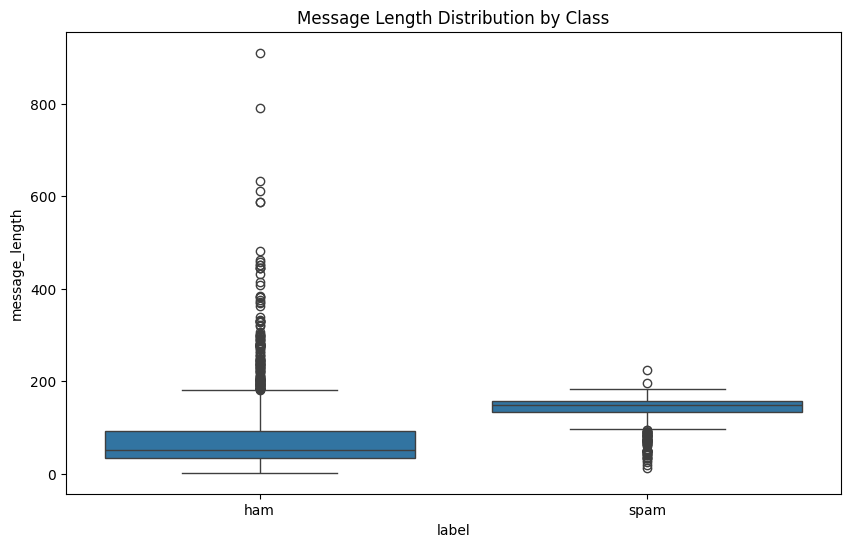

In [46]:
# Creating message_length column
df['message_length'] = df['message'].str.len()

# Now let's plot the boxplot using message_length
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='message_length')
plt.title('Message Length Distribution by Class')

In [47]:
# Creating Keyword-Based Features
spam_keywords = ['free', 'win', 'winner', 'cash', 'prize', 'reward', 'claim',
                 'urgent', 'limited', 'offer', 'call', 'text', 'stop',
                 'guaranteed', 'congratulations', 'selected', 'send', 'click', 'apply']

# Count spam keywords per message
df['spam_keyword_count'] = df['message'].str.lower().str.count('|'.join(spam_keywords))

# Text characteristics features
df['char_count'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()
df['exclamation_count'] = df['message'].str.count('!')
df['capital_ratio'] = df['message'].str.count(r'[A-Z]') / df['char_count']
df['has_numbers'] = df['message'].str.contains(r'\d+').astype(int)
df['has_currency'] = df['message'].str.contains(r'[\$£€]').astype(int)
df['has_url'] = df['message'].str.contains(r'http|www|\.com').astype(int)
df['has_phone'] = df['message'].str.contains(r'\d{3}-\d{3}-\d{4}|\d{10}').astype(int)

In [48]:
# Let's check how well these features separate classes
feature_cols = ['spam_keyword_count', 'char_count', 'exclamation_count', 'capital_ratio','has_numbers', 'has_currency', 'has_url', 'has_phone']
df.groupby('label')[feature_cols].mean()

,spam_keyword_count,char_count,exclamation_count,capital_ratio,has_numbers,has_currency,has_url,has_phone
label,,,,,,,,
ham,0.165596,71.023627,0.173886,0.058200,0.155026,0.003731,0.003109,0.000207
spam,2.318608,138.866131,0.725569,0.110506,0.947791,0.344043,0.159304,0.544846


In [49]:
# The individual engineered feature columns
feature_cols = ['spam_keyword_count', 'char_count', 'exclamation_count',
                'capital_ratio', 'has_numbers', 'has_currency', 'has_url', 'has_phone']
# Convert these columns to a numpy array
engineered_features = df[feature_cols].values  # This creates the feature matrix

The above created engineered features will certainly be of great importance for the spam detector. However, in the next part we will handle the text of messages in order to transform it into vectors that can be used in Deep Learning models. This is the embedding part, for which we will take advantage of an existing embedding model: Sentence Transformers, so we will do some 'Transfer Learning'.

# Text Embedding with Sentence Transformers

In [51]:
# Load pre-trained Sentence Transformer model
# Using 'all-MiniLM-L6-v2' - excellent balance of speed and performance (384 dimensions)
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

In [52]:
# Generate embeddings for all messages
sentence_embeddings = sentence_model.encode(df['message'].tolist(),
                                          show_progress_bar=True,
                                          batch_size=32)

print(f"\n✅ Sentence embeddings generated!")
print(f"📊 Embedding shape: {sentence_embeddings.shape}")
print(f"📐 Embedding dimensions: {sentence_embeddings.shape[1]}")
print(f"📝 Messages processed: {sentence_embeddings.shape[0]:,}")

Batches:   0%|          | 0/175 [00:00<?, ?it/s]


✅ Sentence embeddings generated!
📊 Embedding shape: (5572, 384)
📐 Embedding dimensions: 384
📝 Messages processed: 5,572


In [53]:
# Now let's combine sentence embeddings with the previously engineered features
combined_features = np.concatenate([sentence_embeddings, engineered_features], axis=1)

print(f"\n🎯 Final combined features:")
print(f"  • Sentence embeddings: {sentence_embeddings.shape[1]} dimensions")
print(f"  • Engineered features: {engineered_features.shape[1]} dimensions")
print(f"  • Total combined: {combined_features.shape[1]} dimensions")
print(f"  • Total samples: {combined_features.shape[0]:,}")

# Prepare labels
labels = (df['label'] == 'spam').astype(int).values
print(f"\n📋 Dataset summary:")
print(f"  • Ham messages: {np.sum(labels == 0):,}")
print(f"  • Spam messages: {np.sum(labels == 1):,}")
print(f"  • Imbalance ratio: {np.sum(labels == 0)/np.sum(labels == 1):.1f}:1")


🎯 Final combined features:
  • Sentence embeddings: 384 dimensions
  • Engineered features: 8 dimensions
  • Total combined: 392 dimensions
  • Total samples: 5,572

📋 Dataset summary:
  • Ham messages: 4,825
  • Spam messages: 747
  • Imbalance ratio: 6.5:1


The final dataset that will be used for Deep Learning models is now composed of 5572 rows (as the original one) and 392 columns with features: 8 of them are the engineered ones and 384 are vector dimensions values coming from the embedding model. This means that every single message (row) is represented by a 384 dimensional vector as well as by 8 engineered features.

Furthermore, we observe a significant imbalance between ham and spam messages. This might affect the spam detection in our model and therefor it would be wise to handle this issue in order to give the same weight to both types of messages.

# Data Preparation before Training the Deep Learning (Neural Network) Models

In [54]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    combined_features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [55]:
# Scale the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
# Calculate class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [57]:
print(f"✅ Data splitting completed:")
print(f"  • Training samples: {X_train_scaled.shape[0]:,}")
print(f"  • Test samples: {X_test_scaled.shape[0]:,}")
print(f"  • Feature dimensions: {X_train_scaled.shape[1]}")

print(f"\n✅ Class distribution:")
print(f"  • Train - Ham: {np.sum(y_train == 0):,}, Spam: {np.sum(y_train == 1):,}")
print(f"  • Test - Ham: {np.sum(y_test == 0):,}, Spam: {np.sum(y_test == 1):,}")

print(f"\n✅ Class weights (for handling imbalance):")
print(f"  • Ham weight: {class_weights[0]:.3f}")
print(f"  • Spam weight: {class_weights[1]:.3f}")
print(f"  • Spam is weighted {class_weights[1]/class_weights[0]:.1f}x higher")

✅ Data splitting completed:
  • Training samples: 4,457
  • Test samples: 1,115
  • Feature dimensions: 392

✅ Class distribution:
  • Train - Ham: 3,859, Spam: 598
  • Test - Ham: 966, Spam: 149

✅ Class weights (for handling imbalance):
  • Ham weight: 0.577
  • Spam weight: 3.727
  • Spam is weighted 6.5x higher


In [58]:
# Convert to PyTorch tensors (for the NN models)
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

In [59]:
# Create data loaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [60]:
print(f"\n🚀 Ready for neural network training!")
print(f"  • Batch size: {batch_size}")
print(f"  • Training batches: {len(train_loader)}")
print(f"  • Test batches: {len(test_loader)}")
print(f"  • Device: {device}")


🚀 Ready for neural network training!
  • Batch size: 32
  • Training batches: 140
  • Test batches: 35
  • Device: cuda


# Neural Network Models Architecture

In [61]:
# Let's first define a simple NN model with 3 layers (input, hidden, output)

class SimpleSpamDetector(nn.Module):
    """
    Simple 2-layer neural network optimized for Sentence Transformer embeddings.

    Architecture:
    - Input: 392 features (384 sentence embeddings + 8 engineered features)
    - Hidden Layer: 128 neurons with ReLU activation and dropout
    - Output Layer: 1 neuron with sigmoid activation
    - Total Parameters: ~51K
    """
    def __init__(self, input_size, hidden_size=128, dropout_rate=0.3):
        super(SimpleSpamDetector, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x  # Returns logits for BCEWithLogitsLoss

In [62]:
# Let's simply the above model even more by reducing the number of neurons in the hidden layer

class UltraSimpleSpamDetector(nn.Module):
    """
    Ultra-simple neural network with minimal parameters.

    Architecture:
    - Input: 392 features
    - Hidden Layer: 64 neurons with ReLU activation and dropout
    - Output Layer: 1 neuron
    - Total Parameters: ~25K
    """
    def __init__(self, input_size, hidden_size=64, dropout_rate=0.2):
        super(UltraSimpleSpamDetector, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x  # Returns logits for BCEWithLogitsLoss

In [63]:
# Initialize models
input_size = combined_features.shape[1]
simple_model = SimpleSpamDetector(input_size=input_size).to(device)
ultra_simple_model = UltraSimpleSpamDetector(input_size=input_size).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [64]:
print(f"✅ Models created successfully!")
print(f"\n📊 Model specifications:")
print(f"  • Input size: {input_size} features")
print(f"  • Simple Model: {count_parameters(simple_model):,} parameters")
print(f"  • Ultra-Simple Model: {count_parameters(ultra_simple_model):,} parameters")
print(f"\n🏗️ Architecture Summary:")
print(f"  • Simple: {input_size} → 128 → 1")
print(f"  • Ultra-Simple: {input_size} → 64 → 1")
print(f"  • Both use ReLU activation + Dropout + Class weighting")

✅ Models created successfully!

📊 Model specifications:
  • Input size: 392 features
  • Simple Model: 50,433 parameters
  • Ultra-Simple Model: 25,217 parameters

🏗️ Architecture Summary:
  • Simple: 392 → 128 → 1
  • Ultra-Simple: 392 → 64 → 1
  • Both use ReLU activation + Dropout + Class weighting


We have defined and initialised two NN models. Let's now create a training function with class weighting (in order to adress the significant class imbalance between ham and spam labels).

In [65]:
# Training Function with Class Weighting
def train_neural_network(model, train_loader, test_loader, model_name, epochs=25, learning_rate=0.001):
    """
    Train a neural network with class-weighted loss function to handle imbalance.
    """
    model.to(device)

    # Use weighted loss - crucial for handling class imbalance
    pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    train_losses = []
    val_accuracies = []
    val_aucs = []

    print(f"\n🚀 Training {model_name}...")
    print("=" * 50)

    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        all_probs = []
        all_labels = []

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X).squeeze()
                probs = torch.sigmoid(outputs)
                predicted = (probs > 0.5).float()

                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()

                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        accuracy = correct / total
        avg_loss = total_loss / len(train_loader)
        auc = roc_auc_score(all_labels, all_probs)

        train_losses.append(avg_loss)
        val_accuracies.append(accuracy)
        val_aucs.append(auc)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1:2d}/{epochs}] | Loss: {avg_loss:.4f} | Acc: {accuracy:.4f} | AUC: {auc:.4f}')

    return train_losses, val_accuracies, val_aucs, all_labels, all_probs

# Training Neural Network Models

In [66]:
# Train Simple Model
simple_losses, simple_accuracies, simple_aucs, simple_labels, simple_probs = train_neural_network(
    simple_model, train_loader, test_loader, "Simple Neural Network (128 hidden)", epochs=25
)


🚀 Training Simple Neural Network (128 hidden)...
Epoch [ 5/25] | Loss: 0.0083 | Acc: 0.9892 | AUC: 0.9988
Epoch [10/25] | Loss: 0.0019 | Acc: 0.9892 | AUC: 0.9988
Epoch [15/25] | Loss: 0.0006 | Acc: 0.9910 | AUC: 0.9987
Epoch [20/25] | Loss: 0.0004 | Acc: 0.9919 | AUC: 0.9990
Epoch [25/25] | Loss: 0.0002 | Acc: 0.9928 | AUC: 0.9989


In [67]:
# Preparing the confusion matrix of this model to quickly check on the results
cm = confusion_matrix(simple_labels, (np.array(simple_probs) > 0.5).astype(int))
cm_df = pd.DataFrame(cm, index=['Actual Ham', 'Actual Spam'], columns=['Predicted Ham', 'Predicted Spam'])
cm_df

,Predicted Ham,Predicted Spam
Actual Ham,964,2
Actual Spam,6,143


In [68]:
# Train Ultra-Simple Model
ultra_losses, ultra_accuracies, ultra_aucs, ultra_labels, ultra_probs = train_neural_network(
    ultra_simple_model, train_loader, test_loader, "Ultra-Simple Neural Network (64 hidden)", epochs=25
)


🚀 Training Ultra-Simple Neural Network (64 hidden)...
Epoch [ 5/25] | Loss: 0.0146 | Acc: 0.9883 | AUC: 0.9980
Epoch [10/25] | Loss: 0.0028 | Acc: 0.9892 | AUC: 0.9980
Epoch [15/25] | Loss: 0.0012 | Acc: 0.9883 | AUC: 0.9981
Epoch [20/25] | Loss: 0.0008 | Acc: 0.9919 | AUC: 0.9984
Epoch [25/25] | Loss: 0.0005 | Acc: 0.9928 | AUC: 0.9985


In [69]:
# Preparing the confusion matrix to quickly check the results
cm = confusion_matrix(ultra_labels, (np.array(ultra_probs) > 0.5).astype(int))
cm_df = pd.DataFrame(cm, index=['Actual Ham', 'Actual Spam'], columns=['Predicted Ham', 'Predicted Spam'])
cm_df

,Predicted Ham,Predicted Spam
Actual Ham,963,3
Actual Spam,5,144


In [70]:
# Store results for comparison
results = {
    'Simple NN': {
        'model': simple_model,
        'accuracy': simple_accuracies[-1],
        'auc_score': simple_aucs[-1],
        'y_pred': (np.array(simple_probs) > 0.5).astype(int),
        'y_proba': simple_probs,
        'losses': simple_losses,
        'accuracies': simple_accuracies,
        'aucs': simple_aucs,
        'parameters': count_parameters(simple_model)
    },
    'Ultra-Simple NN': {
        'model': ultra_simple_model,
        'accuracy': ultra_accuracies[-1],
        'auc_score': ultra_aucs[-1],
        'y_pred': (np.array(ultra_probs) > 0.5).astype(int),
        'y_proba': ultra_probs,
        'losses': ultra_losses,
        'accuracies': ultra_accuracies,
        'aucs': ultra_aucs,
        'parameters': count_parameters(ultra_simple_model)
    }
}

In [71]:
print(f"\n TRAINING COMPLETED!")
print("=" * 30)
print(f" Final Results:")
for name, result in results.items():
    print(f"  {name}:")
    print(f"    • Accuracy: {result['accuracy']:.4f}")
    print(f"    • AUC Score: {result['auc_score']:.4f}")
    print(f"    • Parameters: {result['parameters']:,}")
    print()


 TRAINING COMPLETED!
 Final Results:
  Simple NN:
    • Accuracy: 0.9928
    • AUC Score: 0.9989
    • Parameters: 50,433

  Ultra-Simple NN:
    • Accuracy: 0.9928
    • AUC Score: 0.9985
    • Parameters: 25,217



As we can see above both models give good results showing accuracy and AUC score at the same level. It might need a closer look.

# Comprehensive Results Analysis and Visualization

In [72]:
# Find best model
best_model_name = max(results.keys(), key=lambda k: results[k]['auc_score'])
best_model = results[best_model_name]

In [73]:
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 50)
print(f"  • Accuracy: {best_model['accuracy']:.4f} ({best_model['accuracy']:.1%})")
print(f"  • AUC Score: {best_model['auc_score']:.4f}")
print(f"  • Parameters: {best_model['parameters']:,}")

print(f"\n📋 Classification Report ({best_model_name}):")
print("-" * 40)
print(classification_report(simple_labels, best_model['y_pred'], target_names=['Ham', 'Spam']))

🏆 BEST MODEL: Simple NN
  • Accuracy: 0.9928 (99.3%)
  • AUC Score: 0.9989
  • Parameters: 50,433

📋 Classification Report (Simple NN):
----------------------------------------
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       966
        Spam       0.99      0.96      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



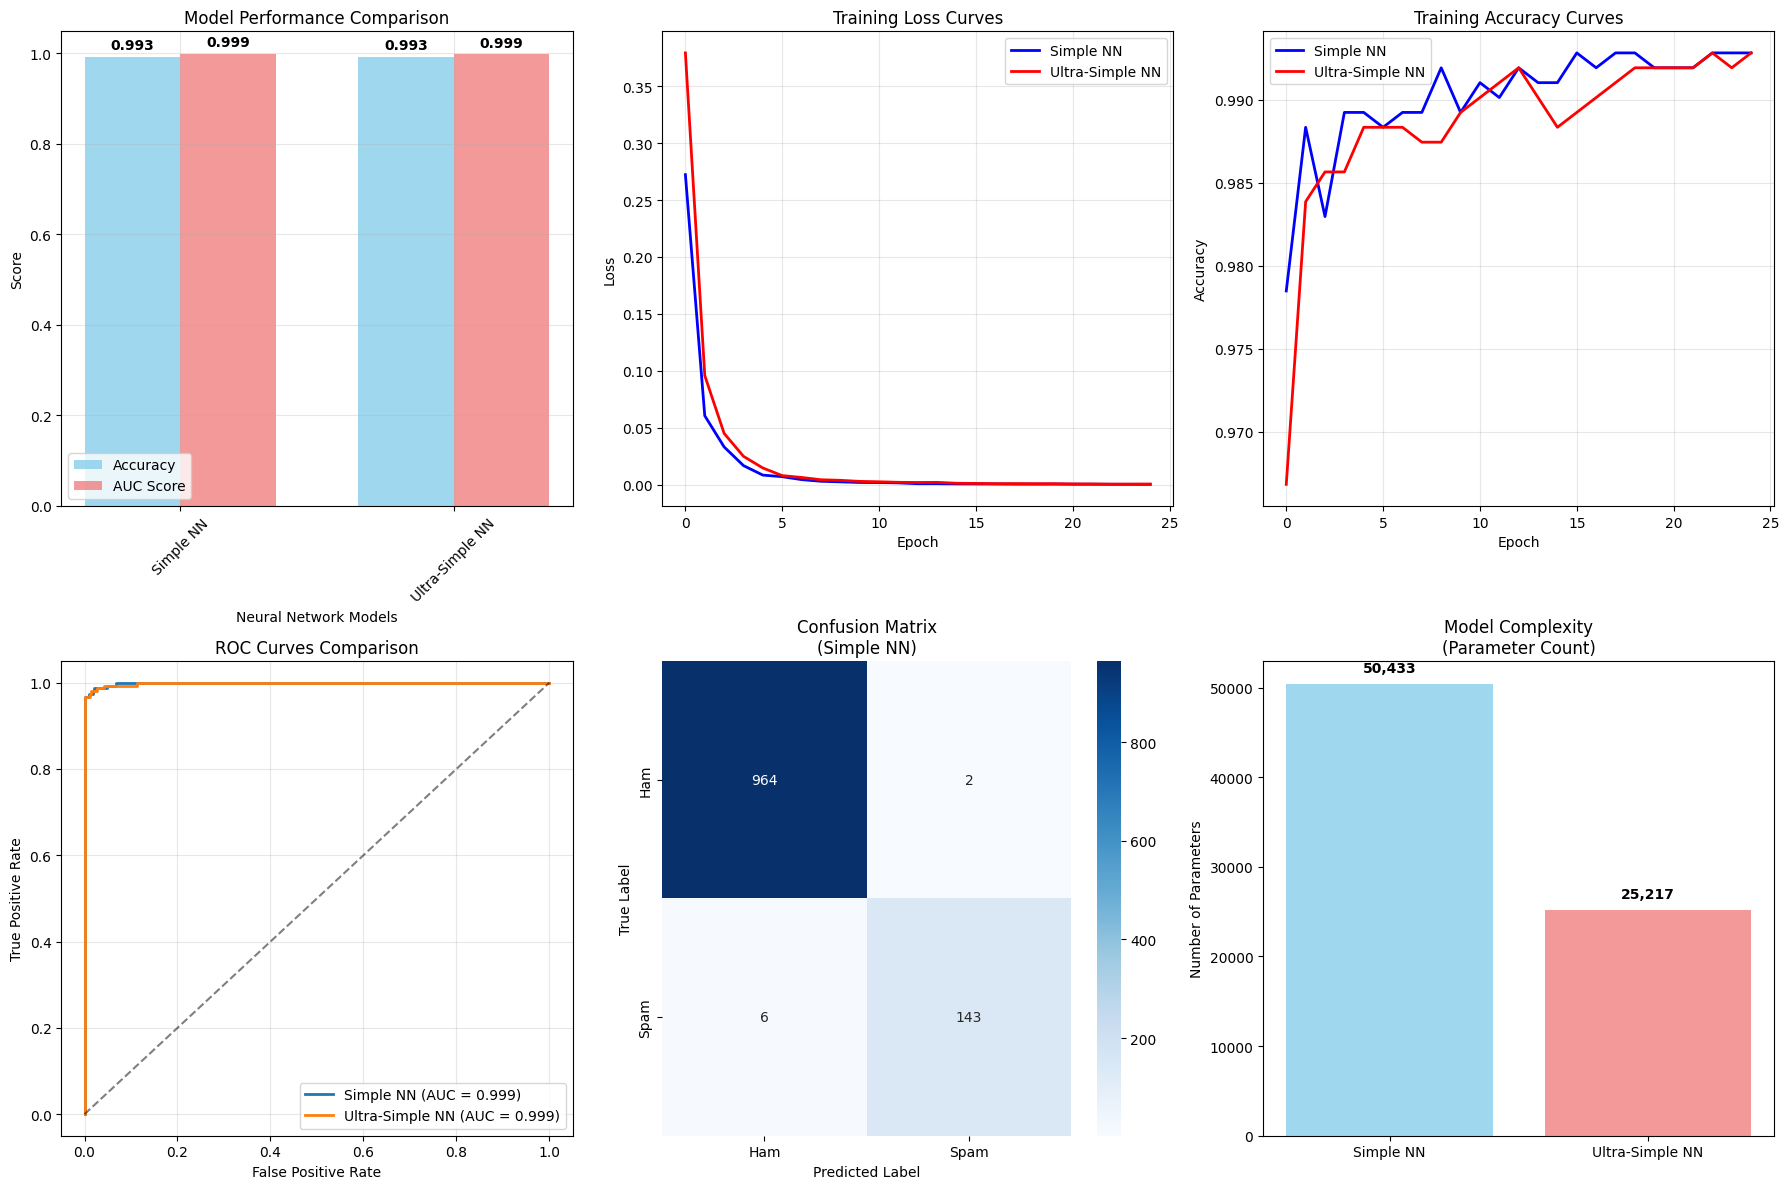


 SENTENCE TRANSFORMERS + NEURAL NETWORKS - FINAL RESULTS
✅ Approach: Modern Transfer Learning (Sentence Transformers + NNs)
✅ Best Model: Simple NN
✅ Final Accuracy: 0.9928 (99.3%)
✅ Final AUC Score: 0.9989
✅ Model Complexity: 50,433 parameters
✅ Total Features: 392 (384 embeddings + 8 engineered)
✅ Dataset: 5,572 messages processed
✅ Class Imbalance: Handled with weighted loss function
✅ Training Device: cuda

 Model ready for deployment!


In [74]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Model Performance Comparison
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
auc_scores = [results[name]['auc_score'] for name in model_names]
param_counts = [results[name]['parameters'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0,0].bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8, color='skyblue')
bars2 = axes[0,0].bar(x + width/2, auc_scores, width, label='AUC Score', alpha=0.8, color='lightcoral')

axes[0,0].set_xlabel('Neural Network Models')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Model Performance Comparison')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(['Simple NN', 'Ultra-Simple NN'], rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Training Loss Curves
axes[0,1].plot(results['Simple NN']['losses'], label='Simple NN', linewidth=2, color='blue')
axes[0,1].plot(results['Ultra-Simple NN']['losses'], label='Ultra-Simple NN', linewidth=2, color='red')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_title('Training Loss Curves')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Training Accuracy Curves
axes[0,2].plot(results['Simple NN']['accuracies'], label='Simple NN', linewidth=2, color='blue')
axes[0,2].plot(results['Ultra-Simple NN']['accuracies'], label='Ultra-Simple NN', linewidth=2, color='red')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Accuracy')
axes[0,2].set_title('Training Accuracy Curves')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. ROC Curves
for name, result in results.items():
    fpr, tpr, _ = roc_curve(simple_labels, result['y_proba'])
    axes[1,0].plot(fpr, tpr, label=f'{name} (AUC = {result["auc_score"]:.3f})', linewidth=2)

axes[1,0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curves Comparison')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Confusion Matrix (Best Model)
cm = confusion_matrix(simple_labels, best_model['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1,1].set_title(f'Confusion Matrix\n({best_model_name})')
axes[1,1].set_ylabel('True Label')
axes[1,1].set_xlabel('Predicted Label')

# 6. Model Complexity Comparison
bars = axes[1,2].bar(['Simple NN', 'Ultra-Simple NN'], param_counts,
                     color=['skyblue', 'lightcoral'], alpha=0.8)
axes[1,2].set_title('Model Complexity\n(Parameter Count)')
axes[1,2].set_ylabel('Number of Parameters')

for bar, param in zip(bars, param_counts):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f'{param:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n SENTENCE TRANSFORMERS + NEURAL NETWORKS - FINAL RESULTS")
print("=" * 65)
print(f"✅ Approach: Modern Transfer Learning (Sentence Transformers + NNs)")
print(f"✅ Best Model: {best_model_name}")
print(f"✅ Final Accuracy: {best_model['accuracy']:.4f} ({best_model['accuracy']:.1%})")
print(f"✅ Final AUC Score: {best_model['auc_score']:.4f}")
print(f"✅ Model Complexity: {best_model['parameters']:,} parameters")
print(f"✅ Total Features: {combined_features.shape[1]} (384 embeddings + 8 engineered)")
print(f"✅ Dataset: {len(df):,} messages processed")
print(f"✅ Class Imbalance: Handled with weighted loss function")
print(f"✅ Training Device: {device}")
print(f"\n Model ready for deployment!")

The above analysis of the results produced by both models indicates clearly that they give comparable performance. The Simple NN performs slightly better, but on the other hand deals with twice as much parameters. So it would be a decision to take if we were to apply it in real life problems: for comparable results, shall we opt for a model with less parameters?

In the last part of this notebook, we may go a step further and run e prediction on some new messages, never seen by the model. This would give us a nice glance of its utility for real life application.

# Prediction Attempt on New Messages

In [75]:
# Production Prediction Demo
def predict_spam_with_sentence_transformers(message, model, scaler, sentence_transformer, feature_cols):
    """
    Complete prediction pipeline using Sentence Transformers + Neural Network
    """
    # Feature engineering for new message
    spam_keywords = ['free', 'win', 'winner', 'cash', 'prize', 'reward', 'claim',
                    'urgent', 'limited', 'offer', 'call', 'text', 'stop',
                    'guaranteed', 'congratulations', 'selected', 'send', 'click', 'apply']

    # Calculate engineered features
    features = {
        'spam_keyword_count': sum(1 for keyword in spam_keywords if keyword in message.lower()),
        'char_count': len(message),
        'exclamation_count': message.count('!'),
        'capital_ratio': sum(1 for c in message if c.isupper()) / max(len(message), 1),
        'has_numbers': int(bool(re.search(r'\d+', message))),
        'has_currency': int(bool(re.search(r'[\$£€]', message))),
        'has_url': int(bool(re.search(r'http|www|\.com', message))),
        'has_phone': int(bool(re.search(r'\d{3}-\d{3}-\d{4}|\d{10}', message)))
    }

    # Generate sentence embedding
    sentence_embedding = sentence_transformer.encode([message])

    # Combine features
    engineered_array = np.array([[features[col] for col in feature_cols]])
    combined_features = np.concatenate([sentence_embedding, engineered_array], axis=1)

    # Scale features
    scaled_features = scaler.transform(combined_features)

    # Predict with neural network
    model.eval()
    with torch.no_grad():
        inputs = torch.FloatTensor(scaled_features).to(device)
        logits = model(inputs).squeeze()
        probability = torch.sigmoid(logits).item()
        prediction = 'SPAM' if probability > 0.5 else 'HAM'

    return prediction, probability

In [76]:
# Test with example messages
test_messages = [
    "Hey, are you free for dinner tonight?",  # Normal message
    "FREE! Win cash prizes now! Call 555-123-4567 to claim your reward!",  # Obvious spam
    "Your package has been delivered to your address",  # Normal notification
    "URGENT! Limited time offer - click here to win £1000 guaranteed!"  # Spam with multiple indicators
]

print("🔮 SENTENCE TRANSFORMERS + NEURAL NETWORK PREDICTION DEMO")
print("=" * 60)

for i, message in enumerate(test_messages, 1):
    prediction, probability = predict_spam_with_sentence_transformers(
        message, best_model['model'], scaler, sentence_model, feature_cols
    )
    print(f"\n📱 Message {i}: '{message[:45]}{'...' if len(message) > 45 else ''}'")
    print(f"🤖 Prediction: {prediction}")
    print(f"📊 Confidence: {probability:.3f}")
    print(f"📈 Spam Probability: {probability:.1%}")

print(f"\n✅ Prediction demo completed!")
print(f"🎯 Best model ({best_model_name}) successfully deployed!")
print(f"💾 Ready for production use with Sentence Transformers + Neural Networks!")

🔮 SENTENCE TRANSFORMERS + NEURAL NETWORK PREDICTION DEMO

📱 Message 1: 'Hey, are you free for dinner tonight?'
🤖 Prediction: HAM
📊 Confidence: 0.000
📈 Spam Probability: 0.0%

📱 Message 2: 'FREE! Win cash prizes now! Call 555-123-4567 ...'
🤖 Prediction: SPAM
📊 Confidence: 1.000
📈 Spam Probability: 100.0%

📱 Message 3: 'Your package has been delivered to your addre...'
🤖 Prediction: HAM
📊 Confidence: 0.000
📈 Spam Probability: 0.0%

📱 Message 4: 'URGENT! Limited time offer - click here to wi...'
🤖 Prediction: SPAM
📊 Confidence: 1.000
📈 Spam Probability: 100.0%

✅ Prediction demo completed!
🎯 Best model (Simple NN) successfully deployed!
💾 Ready for production use with Sentence Transformers + Neural Networks!
